# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Additional Notebook: **LangChain 🦜🔗: Models, Prompts, Output Parsers, Chains, and Memory**

(Ungraded)

## Objectives

At the end of the experiment you will be able to:

* Understand the fundamentals of LangChain and its core components
* Create and use **Prompt Templates** for dynamic prompt generation
* Work with **Chat Models** in LangChain
* Apply **Output Parsers** to structure LLM responses effectively
* Build simple **Chains** by combining prompts and models
* Use **Memory** to maintain context across interactions


## What is LangChain?

**LangChain** is an open-source framework that helps developers **build applications powered by Large Language Models (LLMs)** by providing structured components like prompts, chains, memory, and output parsers.

In simple terms, **LangChain is a framework that makes it easier to design, connect, and manage LLM-powered workflows and applications.**

---

**Why LangChain is Needed**

When working directly with LLM APIs, you often need to:

* Manage prompts manually
* Handle input/output formatting
* Chain multiple steps together
* Maintain conversation context

LangChain simplifies all of this by providing **ready-to-use building blocks**.

---

**Core Idea**

Instead of writing everything from scratch, LangChain lets you **compose LLM applications using modular components**.

---

### Key Components in LangChain

* **Models** → Connect to LLMs (e.g., GPT, Gemini)
* **Prompts** → Structure inputs sent to the model
* **Output Parsers** → Convert model output into structured format
* **Chains** → Link multiple steps together
* **Memory** → Store and use past interactions

Retrieval Layer Components

* **Document Loaders** → Load data from various sources (PDFs, APIs, databases) into the system
* **Document Transformers** → Clean, split, and preprocess documents for better handling
* **Embedding Models** → Convert text into numerical vectors for semantic understanding
* **Vector Stores** → Store and index embeddings for efficient similarity search
* **Retrievers** → Fetch the most relevant documents based on a query

Advanced Components

* **Agents** → Enable LLMs to make decisions and dynamically choose actions/tools
* **Tools** → External functions/APIs that agents use to perform tasks (e.g., search, calculations)

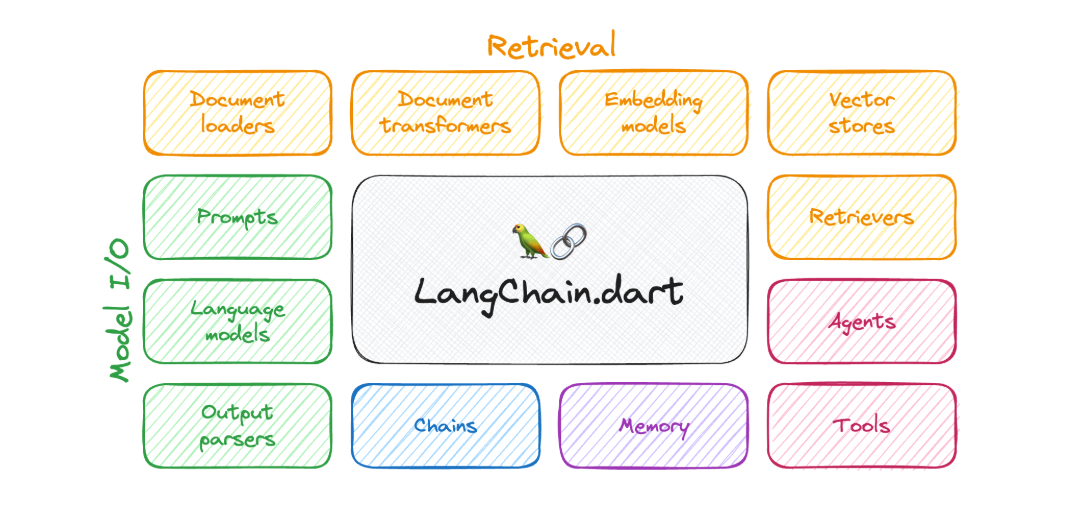

In this notebook, the focus will be on Prompts, Language Models, Output Parsers, Chains, and Memory.

The remaining components will be covered in future modules.

---

**How It Works**

```text
User Input
   ↓
Prompt Template
   ↓
LLM (Model)
   ↓
Output Parser
   ↓
Final Response
```


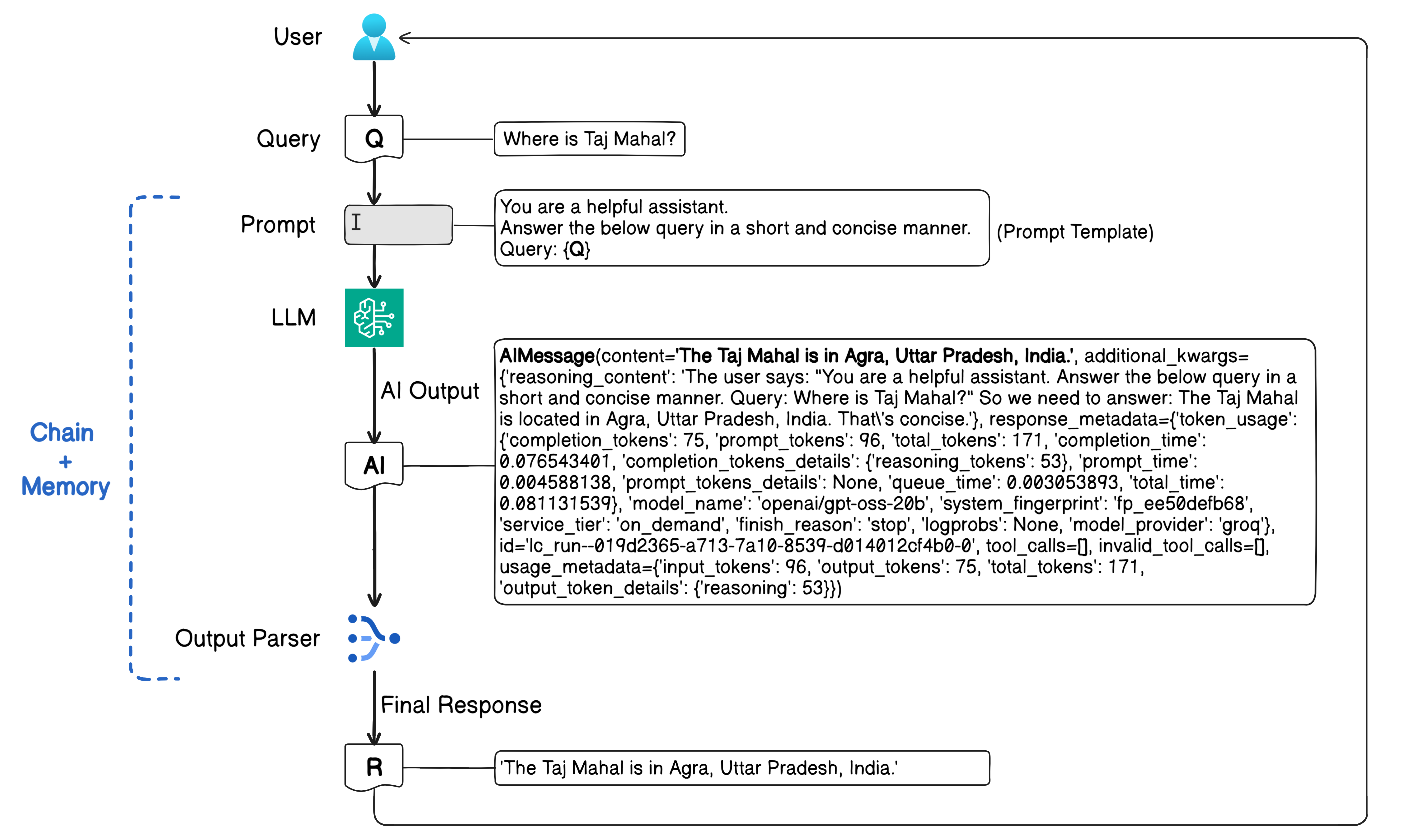

---

**What You Can Build with LangChain**

* Chatbots and conversational assistants
* Document analysis tools
* Automated workflows
* Multi-step reasoning pipelines
* AI-powered business applications

---


### Install Required Libraries

In [1]:
%%capture
!pip -q install groq==0.37.1
!pip -q install langchain-groq==1.1.2
!pip -q install langchain==1.2.12
!pip -q install langchain-core==1.2.19
!pip -q install langchain_community==0.4.1

### Read the Groq API Key

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [2]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

## **Models**

**Models in LangChain** are the components that **interface with Large Language Models (LLMs)** to generate responses based on given prompts.

They are the layer in LangChain that connects your application to LLM providers (like GPT, Gemini, Groq, etc.) and produces outputs.

---

**Types of Models in LangChain**

1. **Chat Models**

   * Designed for conversational interactions
   * Accept messages
      - system: `SystemMessage()` - to set the role and behaviour for LLM
      - user: `HumanMessage()` - to provide input to LLM
      - assistant: `AIMessage()` - the response from LLM
   * Example: GPT-style chat models

        ```
        messages=[
            {"role": "system", "content": "You are a helpful assistant. Answer all questions to the best of your ability."},
            {"role": "user", "content": "Hi my name is Aman! what is 1+1?"},
            {"role": "assistant", "content": "Hi Aman! 1 + 1 equals 2."},
            {"role": "user", "content": "Do you remember my name?"},
            {"role": "assistant", "content": "Yes, your name is Aman! How can I assist you today?"},
            {"role": "user", "content": "Write a short brief on Prompt Engineering."},
        ]
        ```
    
        Chat Model Example:

        ```python
        import os
        from langchain_openai import ChatOpenAI
        from langchain_core.messages import HumanMessage, SystemMessage

        os.environ["OPENAI_API_KEY"] = "sk-..."

        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0.7,
            max_tokens=150
        )

        messages = [
            SystemMessage(content="You are a helpful AI assistant."),
            HumanMessage(content="Explain LangChain in simple terms.")
        ]

        response = llm.invoke(messages)

        print(response.content)
        ```

2. **LLMs (Completion Models)**

   * Work with plain text prompts
   * Generate direct text completions
      
      Completion Model Example:
      ```python
      from langchain.llms import OpenAI

      # Initialize LLM (Completion Model)
      llm = OpenAI(
          model_name="gpt-3.5-turbo-instruct",  # completion-style model
          temperature=0.7,
          max_tokens=100
      )

      # Direct text prompt
      response = llm.invoke("Explain what is Prompt Engineering in simple terms.")

      print(response)
      ```

3. **Embedding Models** (The details on this will be covered during the RAG session in future modules)
    * Convert text into numerical vector representations
    * Capture semantic meaning of text
    * Used for similarity search, clustering, and retrieval tasks (e.g., RAG)

        Embedding Model Example:

        ```python
        from langchain.embeddings import HuggingFaceEmbeddings

        # Initialize HuggingFace embedding model
        embeddings = HuggingFaceEmbeddings(
            model_name="sentence-transformers/all-MiniLM-L6-v2"
        )

        # Input text
        text = "LangChain helps build LLM applications."

        # Generate embedding vector
        vector = embeddings.embed_query(text)

        # Print first 5 values
        print(vector[:5])
        ```



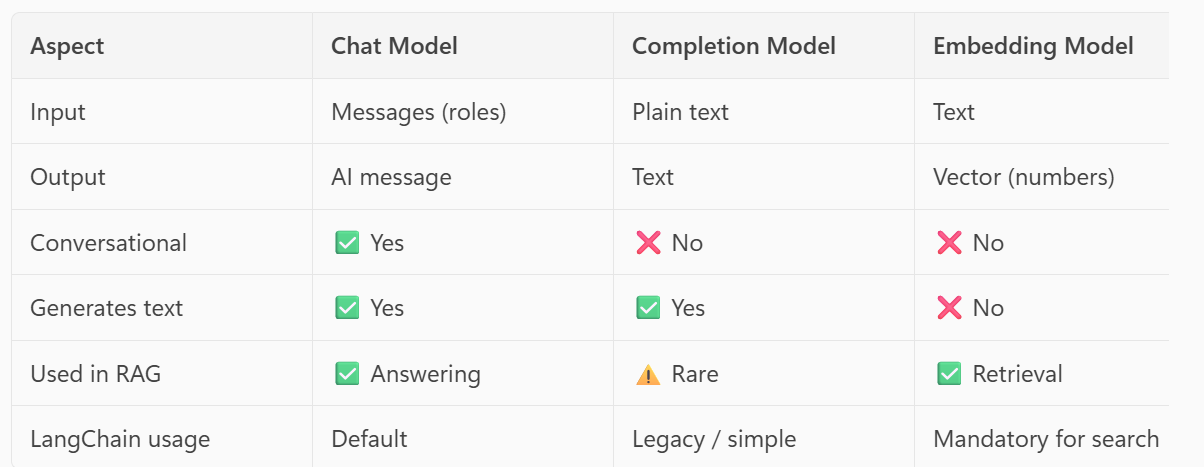

---

**What Models Do**

* Take **input prompts**
* Process them using an underlying LLM
* Generate **text responses or structured outputs**

---

**Key Responsibilities**

* Connecting to external LLM APIs
* Handling parameters like:

  * temperature
  * max tokens
  * top-p / top-k
* Returning model-generated outputs

---

**Initialize a Chat Model**

In [3]:
from langchain_groq import ChatGroq     # <--- This is a langchain abstraction for the Groq API endpoint

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

In [4]:
llm.model_name

'openai/gpt-oss-20b'

In [5]:
response = llm.invoke("""
You are a helpful assistant.
Answer the below query in a short and concise manner.
Query: Where is Taj Mahal?
""")

response

AIMessage(content='The Taj Mahal is located in Agra, Uttar Pradesh, India.', additional_kwargs={'reasoning_content': 'We need to answer concisely: Taj Mahal is in Agra, Uttar Pradesh, India.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 96, 'total_tokens': 140, 'completion_time': 0.046523852, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.004932593, 'prompt_tokens_details': None, 'queue_time': 0.010101953, 'total_time': 0.051456445}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_dd097e8790', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29cb-29f0-7340-86c3-50e45ad006ab-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 44, 'total_tokens': 140, 'output_token_details': {'reasoning': 21}})

In [6]:
response.content

'The Taj Mahal is located in Agra, Uttar Pradesh, India.'

In [7]:
# Using Messages

from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage(content="You are a helpful assistant. Answer the below query in a short and concise manner."),
    HumanMessage(content="Where is Taj Mahal?")
]

response = llm.invoke(messages)

response

AIMessage(content='The Taj\u202fMahal is located in Agra, Uttar\u202fPradesh, India.', additional_kwargs={'reasoning_content': 'The user asks: "Where is Taj Mahal?" They want location. Provide concise answer: It\'s in Agra, Uttar Pradesh, India. Probably mention it\'s a mausoleum built by Shah Jahan. But keep short.'}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 96, 'total_tokens': 168, 'completion_time': 0.089166882, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.00455835, 'prompt_tokens_details': None, 'queue_time': 0.00311475, 'total_time': 0.093725232}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8e23cedc90', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29cb-2abe-75e0-92de-b0c8856293c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 72, 'total_tokens': 168, 'output_token_details': {'reasoning

In [8]:
response.content

'The Taj\u202fMahal is located in Agra, Uttar\u202fPradesh, India.'

---
---

## **Prompt Template**

**Prompt Templates in LangChain** are used to **create dynamic and reusable prompts** by inserting variables into predefined text structures.

---

**Why Prompt Templates are Used**

* Avoid rewriting prompts repeatedly
* Enable dynamic input handling
* Ensure consistency in prompt design
* Make prompts reusable across applications

---

**How It Works**

A template contains placeholders (variables) that are filled at runtime.

---

**Example**

```python
from langchain_core.prompts import PromptTemplate

template = "Explain {topic} in simple terms."

prompt = PromptTemplate(
    input_variables=["topic"],
    template=template
)

final_prompt = prompt.format(topic="LangChain")

print(final_prompt)
```

Output:

```text
Explain LangChain in simple terms.
```

---

**Key Features**

* Supports **variable substitution**
* Enables **dynamic prompt generation**
* Integrates easily with chains and models
* Helps standardize prompt structures

---

**Types of Prompt Templates**

* **PromptTemplate** → For plain text prompts
* **ChatPromptTemplate** → For chat-based models (system, user messages)

---

Other methods to create Prompt Template:

* `PromptTemplate.from_template()`: Suitable for single-turn, non-chat prompts.

* `ChatPromptTemplate.from_template()`: Suitable for crafting single-turn chat prompts, typically involving chat models.

* `ChatPromptTemplate.from_messages()`: Suitable for multi-turn, conversational chat prompts, where the entire chat history is constructed from previous messages.

**Example 1:** Translation

In [9]:
template_string = """
Translate the text into {lang}.
Text:
```
{text}
```
"""

In [10]:
from langchain_core.prompts import ChatPromptTemplate

prompt_template1 = ChatPromptTemplate.from_template(template_string)
prompt_template1

ChatPromptTemplate(input_variables=['lang', 'text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['lang', 'text'], input_types={}, partial_variables={}, template='\nTranslate the text into {lang}.\nText:\n```\n{text}\n```\n'), additional_kwargs={})])

In [11]:
prompt_template1.messages[0].prompt

PromptTemplate(input_variables=['lang', 'text'], input_types={}, partial_variables={}, template='\nTranslate the text into {lang}.\nText:\n```\n{text}\n```\n')

We can now repeatedly use this template:

In [12]:
prompt_template1.invoke({"lang": "French", "text": "Hello everyone"})

ChatPromptValue(messages=[HumanMessage(content='\nTranslate the text into French.\nText:\n```\nHello everyone\n```\n', additional_kwargs={}, response_metadata={})])

In [13]:
print(prompt_template1.invoke({"lang": "French", "text": "Hello everyone"}).messages[0].content)


Translate the text into French.
Text:
```
Hello everyone
```



In [14]:
print(prompt_template1.invoke({"lang": "Spanish", "text": "Nice to meet you"}).messages[0].content)


Translate the text into Spanish.
Text:
```
Nice to meet you
```



In [15]:
# LLM call

formatted_prompt = prompt_template1.invoke({"lang": "French", "text": "Hello everyone"})

response = llm.invoke(formatted_prompt)
response.content

'Bonjour à tous.'

**Example 2:** Text Classification

In [16]:
prompt = """
Classify the below text as either Positive, Negative, or Neutral.
Text:
{input_text}
"""

In [17]:
prompt_template2 = ChatPromptTemplate.from_template(prompt)
prompt_template2

ChatPromptTemplate(input_variables=['input_text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input_text'], input_types={}, partial_variables={}, template='\nClassify the below text as either Positive, Negative, or Neutral.\nText:\n{input_text}\n'), additional_kwargs={})])

In [18]:
print(prompt_template2.invoke({"input_text": "I like the movie"}).messages[0].content)


Classify the below text as either Positive, Negative, or Neutral.
Text:
I like the movie



In [19]:
print(prompt_template2.invoke({"input_text": "Movie was bad"}).messages[0].content)


Classify the below text as either Positive, Negative, or Neutral.
Text:
Movie was bad



In [20]:
# LLM call

formatted_prompt = prompt_template2.invoke({"input_text": "I like the movie"})

response = llm.invoke(formatted_prompt)
response

AIMessage(content='Positive', additional_kwargs={'reasoning_content': 'We need to classify sentiment. The text: "I like the movie". That\'s positive. So output "Positive".'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 93, 'total_tokens': 127, 'completion_time': 0.035871579, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.005251946, 'prompt_tokens_details': None, 'queue_time': 0.04769402, 'total_time': 0.041123525}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_976a85d17a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29cb-2e45-75d1-9167-0d85e88babca-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 93, 'output_tokens': 34, 'total_tokens': 127, 'output_token_details': {'reasoning': 24}})

In [21]:
response.content

'Positive'

---
---

## **Output Parsers**

**Output Parsers in LangChain** are used to **convert raw LLM responses into structured and usable formats** such as JSON, lists, or custom objects.

They transform unstructured LLM output into structured data that can be easily processed by applications.

---

**Why Output Parsers are Needed**

LLMs typically generate **free-form text**, which can be:

* inconsistent
* hard to process programmatically

Output Parsers help by:

* enforcing structure
* improving reliability
* making outputs machine-readable

---

**Common Types of Output Parsers**

* **StrOutputParser** → Returns plain text
* **JSON Parser** → Converts output into JSON format
* **Pydantic Parser** → Maps output to structured Python objects
* **List Parser** → Extracts lists from responses

---

**Key Benefits**

* Ensures **consistent output format**
* Enables **easy integration with applications**
* Reduces ambiguity in LLM responses
* Supports **automation and pipelines**

---

#### **Extracting text message from AI output**

**StrOutputParser**

The **StrOutputParser** in LangChain is a tool used to convert the output from LLMs into a simplified string format.

In [22]:
from langchain_core.output_parsers import StrOutputParser

In [23]:
# Response from model
response

AIMessage(content='Positive', additional_kwargs={'reasoning_content': 'We need to classify sentiment. The text: "I like the movie". That\'s positive. So output "Positive".'}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 93, 'total_tokens': 127, 'completion_time': 0.035871579, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.005251946, 'prompt_tokens_details': None, 'queue_time': 0.04769402, 'total_time': 0.041123525}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_976a85d17a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d29cb-2e45-75d1-9167-0d85e88babca-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 93, 'output_tokens': 34, 'total_tokens': 127, 'output_token_details': {'reasoning': 24}})

In [24]:
# Intantiate Parser
str_parser = StrOutputParser()

In [25]:
str_parser.invoke(response)

'Positive'

#### **Extracting specific fields**

Parse the LLM output string into a structured data using **PydanticOutputParser**.

***Pydantic*** is a Python library used for data validation and structured data modeling using type hints.

***PydanticOutputParser*** is a LangChain component that uses Pydantic models to **convert LLM output into structured, validated objects**.


Example 1: Simple data validation using Pydantic

In [26]:
from pydantic import BaseModel     # <-- Pydantic - a Data Validation library

class Person(BaseModel):
    name: str
    age: int

In [27]:
p1 = Person(name="Joy", age=28)
p1

Person(name='Joy', age=28)

In [28]:
p2 = Person(name="Aman", age="30")    # <--- note the age is passed as string. The value should be parsed
p2

Person(name='Aman', age=30)

In [29]:
p3 = Person(name="Aman", age="thirty")    # <--- this should through a ValidationError as parsing will fail
p3

ValidationError: 1 validation error for Person
age
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='thirty', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/int_parsing

---

Example 2: Extract required fields from text

**Given below are examples of customer reviews:**

In [30]:
customer_review_1 = """\
This vacuum cleaner is absolutely fantastic. It comes with four different modes: light suction, medium breeze,\
strong wind, and cyclone power. It was delivered within three days, just in time for my husband's birthday surprise.\
I believe he was really impressed by it. Up to now, I've been the only one operating it, and I've been using it\
regularly to tidy up the floors in our home. It does cost a bit more than other vacuum cleaners on the market,\
but in my opinion, it's totally worth the investment considering its extra functionalities.
"""

In [31]:
customer_review_2 = """\
This leaf blower is pretty amazing.  It has four settings:\
candle blower, gentle breeze, windy city, and tornado. \
It arrived in two days, just in time for my wife's \
anniversary present. \
I think my wife liked it so much she was speechless. \
So far I've been the only one using it, and I've been \
using it every other morning to clear the leaves on our lawn. \
It's slightly more expensive than the other leaf blowers \
out there, but I think it's worth it for the extra features.
"""

From above customer reviews, we want to extract information similar to below:

```
{
  "gift": True,
  "delivery_days": 2,
  "price_value": "slightly more expensive than the other leaf blowers out there, but I think it's worth it for the extra features"
}
```

In [32]:
# Create Prompt template

review_template = """
For the following text, extract the following information:

gift: Was the item purchased as a gift or present for someone else? \
Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product \
to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,\
and output them as a comma separated Python list.

Format the output as JSON with the following keys:
gift
delivery_days
price_value

Text: {text}
"""

from langchain_core.prompts import ChatPromptTemplate

prompt_template = ChatPromptTemplate.from_template(review_template)
prompt_template

ChatPromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='\nFor the following text, extract the following information:\n\ngift: Was the item purchased as a gift or present for someone else? Answer True if yes, False if not or unknown.\n\ndelivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.\n\nprice_value: Extract any sentences about the value or price,and output them as a comma separated Python list.\n\nFormat the output as JSON with the following keys:\ngift\ndelivery_days\nprice_value\n\nText: {text}\n'), additional_kwargs={})])

In [33]:
# Get formatted prompt messages

prompt_messages = prompt_template.invoke({"text": customer_review_1})
print(prompt_messages.messages)

[HumanMessage(content="\nFor the following text, extract the following information:\n\ngift: Was the item purchased as a gift or present for someone else? Answer True if yes, False if not or unknown.\n\ndelivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.\n\nprice_value: Extract any sentences about the value or price,and output them as a comma separated Python list.\n\nFormat the output as JSON with the following keys:\ngift\ndelivery_days\nprice_value\n\nText: This vacuum cleaner is absolutely fantastic. It comes with four different modes: light suction, medium breeze,strong wind, and cyclone power. It was delivered within three days, just in time for my husband's birthday surprise.I believe he was really impressed by it. Up to now, I've been the only one operating it, and I've been using itregularly to tidy up the floors in our home. It does cost a bit more than other vacuum cleaners on the market,but in my opinion, it's tot

In [34]:
print(prompt_messages.messages[0].content)


For the following text, extract the following information:

gift: Was the item purchased as a gift or present for someone else? Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,and output them as a comma separated Python list.

Format the output as JSON with the following keys:
gift
delivery_days
price_value

Text: This vacuum cleaner is absolutely fantastic. It comes with four different modes: light suction, medium breeze,strong wind, and cyclone power. It was delivered within three days, just in time for my husband's birthday surprise.I believe he was really impressed by it. Up to now, I've been the only one operating it, and I've been using itregularly to tidy up the floors in our home. It does cost a bit more than other vacuum cleaners on the market,but in my opinion, it's totally worth the investment considering

In [35]:
# LLM call

response = llm.invoke(prompt_messages)
print(response.content)

```json
{
  "gift": true,
  "delivery_days": 3,
  "price_value": [
    "It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."
  ]
}
```


In [36]:
type(response.content)    # the response is a string, and individual fields can't be extracted

str

In [37]:
# Create Class for Custom Object

from pydantic import BaseModel, Field

# Pydantic
class ProductInfo(BaseModel):
    """ Product service info."""

    gift: bool = Field(description="Was the item purchased\
                             as a gift for someone else? \
                             Answer True if yes,\
                             False if not or unknown.")
    delivery_days: int = Field(description="How many days\
                                      did it take for the product\
                                      to arrive? If this \
                                      information is not found,\
                                      output -1.")
    price_value: list[str] = Field(description="Extract any\
                                    sentences about the value or \
                                    price, and output them as a \
                                    comma separated Python list."
    )

In [38]:
# Set up a parser + inject instructions into the prompt template.

from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

pydantic_parser = PydanticOutputParser(pydantic_object=ProductInfo)

In [39]:
# Actual LLM output
response

AIMessage(content='```json\n{\n  "gift": true,\n  "delivery_days": 3,\n  "price_value": [\n    "It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it\'s totally worth the investment considering its extra functionalities."\n  ]\n}\n```', additional_kwargs={'reasoning_content': 'We need to parse the text. Determine gift: "It was delivered within three days, just in time for my husband\'s birthday surprise." That indicates it was a gift for husband. So gift: True.\n\ndelivery_days: "delivered within three days" => 3 days.\n\nprice_value: Extract any sentences about the value or price. Sentences: "It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it\'s totally worth the investment considering its extra functionalities." Also maybe earlier: "It does cost a bit more than other vacuum cleaners on the market" is part of same sentence. So we need to output sentences about value or price. The sentence: "It does cost a bit more 

In [40]:
# Apply Parser

result = pydantic_parser.invoke(response)
result

ProductInfo(gift=True, delivery_days=3, price_value=["It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."])

In [41]:
# Extract individual fields

print(result.gift)
print(result.delivery_days)
print(result.price_value)

True
3
["It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."]


---
---

## **LangChain: Chains**

**Chains in LangChain** are used to **combine multiple components (like prompts, models, and parsers) into a single workflow** to accomplish a task.

It is a sequence of steps where the output of one component becomes the input to the next.

---

**Why Chains are Used**

* Automate multi-step LLM workflows
* Connect prompts, models, and parsers seamlessly
* Improve modularity and reusability
* Enable structured and scalable pipelines

---

**LCEL - LangChain Expression Language**

**LCEL** is a **declarative way to build and connect LangChain components** like prompts, models, and parsers into pipelines using a simple syntax.

It is a concise syntax (using operators like `|`) to compose chains and define LLM workflows in LangChain.

---

**Why LCEL is Used**

* Simplifies building chains
* Makes workflows more readable and compact
* Enables easy composition of components
* Supports streaming, parallelism, and advanced flows

---

**How It Works**

LCEL connects components using the pipe (`|`) operator:

```
chain = prompt | llm | parser
```

When we call `invoke()` on the chain, the input is first passed to prompt, output of that is passed to the llm, and so on.

---

In [42]:
prompt_template

ChatPromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='\nFor the following text, extract the following information:\n\ngift: Was the item purchased as a gift or present for someone else? Answer True if yes, False if not or unknown.\n\ndelivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.\n\nprice_value: Extract any sentences about the value or price,and output them as a comma separated Python list.\n\nFormat the output as JSON with the following keys:\ngift\ndelivery_days\nprice_value\n\nText: {text}\n'), additional_kwargs={})])

In [43]:
# Create Chain

llm_chain = prompt_template | llm | pydantic_parser

In [44]:
output = llm_chain.invoke({"text": customer_review_1})
output

ProductInfo(gift=True, delivery_days=3, price_value=["It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."])

In [45]:
print(output.gift)
print(output.delivery_days)
print(output.price_value)

True
3
["It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."]


Let's see how to turn Python functions into pipe-compatible functions.

#### **Runnable**

A **Runnable** is a unit of execution in the LangChain framework. It represents a specific task or operation that can be performed.

Examples of Runnables include data transformations, computations, or any other operation that can be expressed in the LCEL.

**Example 1: Runnable Lambda**

The RunnableLambda is a LangChain abstraction that allows us to ***turn Python functions into pipe-compatible functions***, similar to the Runnable class.

In [46]:
from langchain_core.runnables import RunnableLambda

In [47]:
def add_five(x):
    return x + 5

def multiply_by_two(x):
    return x * 2

# wrap the functions with RunnableLambda
chain = RunnableLambda(add_five) | RunnableLambda(multiply_by_two)


In [48]:
chain.invoke(2)

14

In [49]:
# Lambda Functions in Python

func = lambda x,y : x+y
func(2,3)

5

In [50]:
# A RunnableSequence constructed using the `|` operator
sequence = RunnableLambda(lambda x: x + 5) | RunnableLambda(lambda x: x * 2)

sequence.invoke(2)

14

Update the Customer Review process chain to show customized output:

In [51]:
def show_output(x: ProductInfo):
    output = ""
    if x.gift:
        output += "The item was a gift\n"
    else:
        output += "The item was not a gift\n"
    output += f"Delivery days: {x.delivery_days}\n"
    output += f"Price value: {x.price_value}\n"
    return output

In [52]:
llm_chain2 = prompt_template | llm | pydantic_parser | RunnableLambda(show_output)

# OR

# llm_chain2 = llm_chain | RunnableLambda(show_output)

In [53]:
output = llm_chain2.invoke({"text": customer_review_1})

print(output)

The item was a gift
Delivery days: 3
Price value: ["It does cost a bit more than other vacuum cleaners on the market, but in my opinion, it's totally worth the investment considering its extra functionalities."]



---
---

## **LangChain: Memory**

**Memory in LangChain** is used to **store and retrieve past interactions**, allowing the model to maintain context across multiple steps or conversations.

It Memory enables LangChain applications to remember previous inputs and outputs to provide context-aware responses.

---

**Why Memory is Needed**

* Maintain conversation continuity
* Avoid repeating information
* Enable personalized and context-aware responses
* Support multi-turn interactions

---

**How It Works**

```text
User Input → Memory (past context) → Prompt → Model → Response → Memory Update
```

Memory is continuously updated with new interactions.

---

**Key Benefits**

* Enables **context-aware conversations**
* Improves user experience
* Supports multi-step workflows
* Reduces need to repeat inputs

---

In [54]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

In [55]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant. Answer all questions to the best of your ability."),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
    ]
)

chain = prompt | llm | str_parser      # LCEL

In [56]:
# To store chat history
store = {}

# Function to retreive chat history as per session id
def get_session_history(session_id: str):
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

# Create a Chain with chat history
chain_with_message_history = RunnableWithMessageHistory(
    chain,
    get_session_history=get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
)

In [57]:
# Pass input for user1
result = chain_with_message_history.invoke(
    {"input": "Hi my name is Aman! what is 1+1?"},
    {"configurable": {"session_id": "user1"}},
)

print(result)

Hi Aman! 1 + 1 equals **2**.


In [58]:
# Check the chat hostory for user1
get_session_history("user1").messages

[HumanMessage(content='Hi my name is Aman! what is 1+1?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hi Aman! 1\u202f+\u202f1 equals **2**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [59]:
# Pass input for user1 again
result = chain_with_message_history.invoke(
    input = {"input": "Do you remember my name?"},
    config = {"configurable": {"session_id": "user1"}}
)

print(result)

Yes, you mentioned that your name is **Aman**.


In [60]:
# Check chat history for user1
get_session_history("user1").messages

[HumanMessage(content='Hi my name is Aman! what is 1+1?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hi Aman! 1\u202f+\u202f1 equals **2**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Do you remember my name?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Yes, you mentioned that your name is **Aman**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [61]:
# Pass input for user2

result = chain_with_message_history.invoke(
    {"input": "Hi my name is Rashi! what is 2 plus 3?"},
    {"configurable": {"session_id": "user2"}},
)

print(result)

Hi Rashi! 2 plus 3 equals **5**.


In [62]:
# Check chat history for user2

get_session_history("user2").messages

[HumanMessage(content='Hi my name is Rashi! what is 2 plus 3?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hi Rashi! 2 plus 3 equals **5**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [63]:
# Check chat history for user1;  There should be no change in it.

get_session_history("user1").messages

[HumanMessage(content='Hi my name is Aman! what is 1+1?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hi Aman! 1\u202f+\u202f1 equals **2**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Do you remember my name?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Yes, you mentioned that your name is **Aman**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [64]:
# Pass input to check user2 name

result = chain_with_message_history.invoke(
    input = {"input": "Do you remember my name?"},
    config = {"configurable": {"session_id": "user2"}}
)

print(result)

Yes, you mentioned that your name is **Rashi**.


In [65]:
# Pass input to check user1 name

result = chain_with_message_history.invoke(
    input = {"input": "Do you remember my name ?"},
    config = {"configurable": {"session_id": "user1"}}
)

print(result)

Yes, you said your name is **Aman**.


---

<center>
$END$
</center>

---